In [2]:
#Importing Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.regressionplots import influence_plot
import statsmodels.formula.api as smf
import numpy as np

In [4]:
# Importing the data set.

df=pd.read_csv('ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [6]:
# Summary Statistics

# Display basic summary statistics
print(df.describe())

# Display data types and missing values information
print(df.info())

              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min     1300.00000     2.0

In [8]:
# Exploratory Data Analysis and Visualizations.

import matplotlib.pyplot as plt
# Check for missing values
print(df.isnull().sum())

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


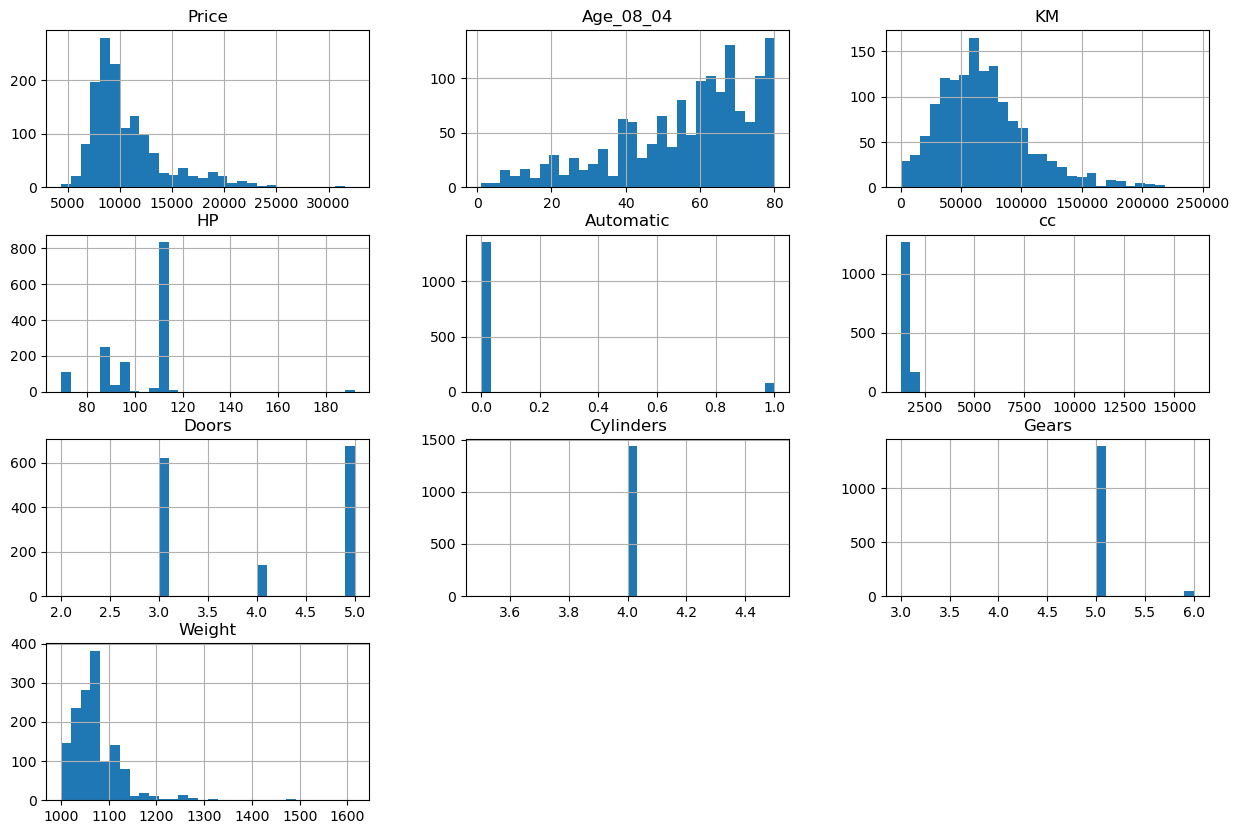

In [10]:
# Histograms for numerical variables

df.hist(bins=30, figsize=(15, 10))
plt.show()

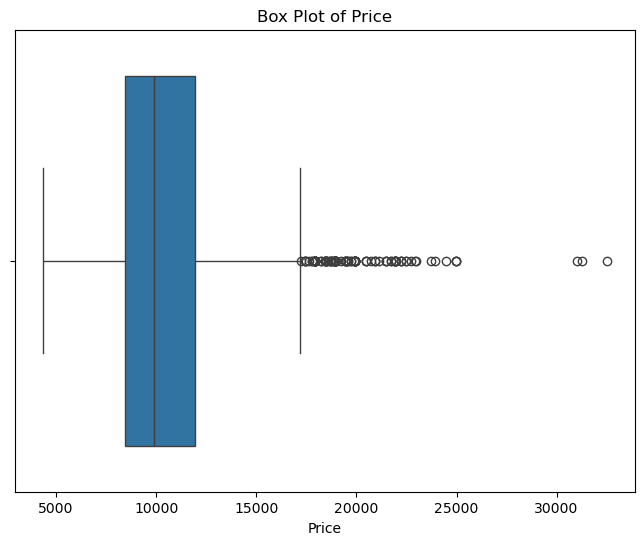

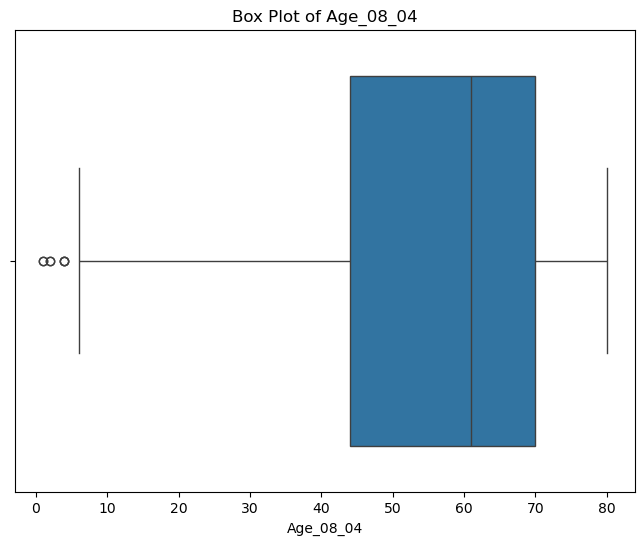

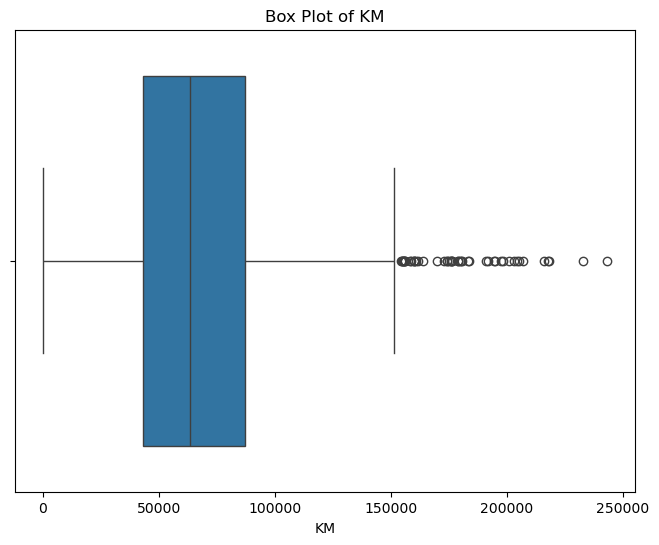

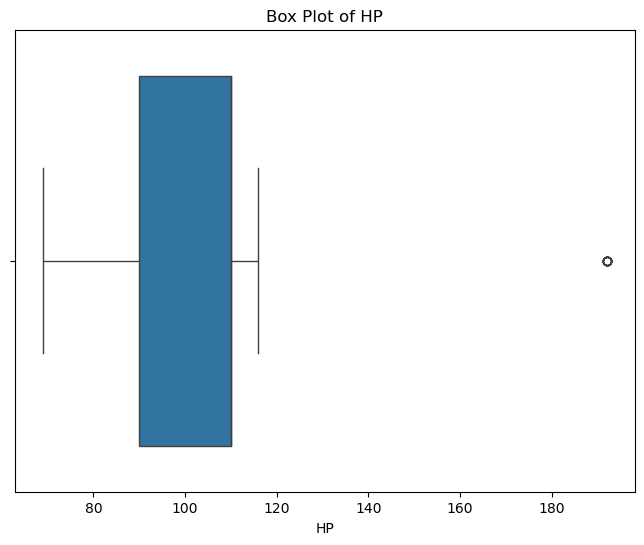

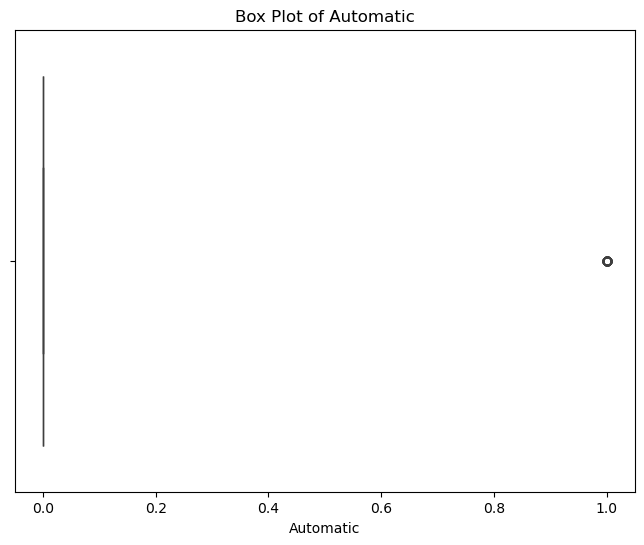

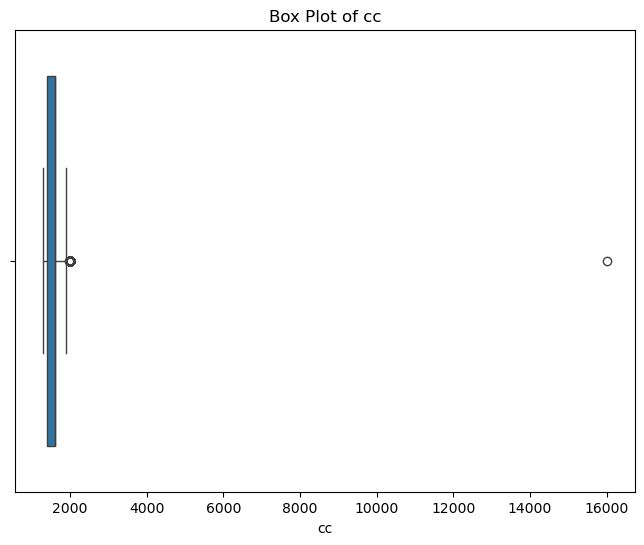

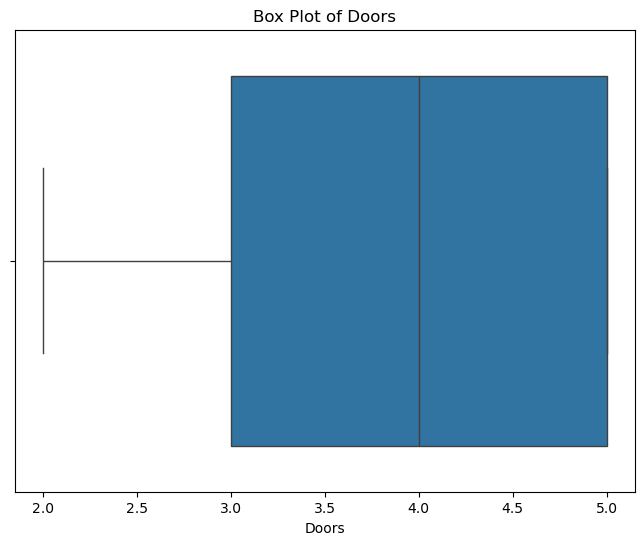

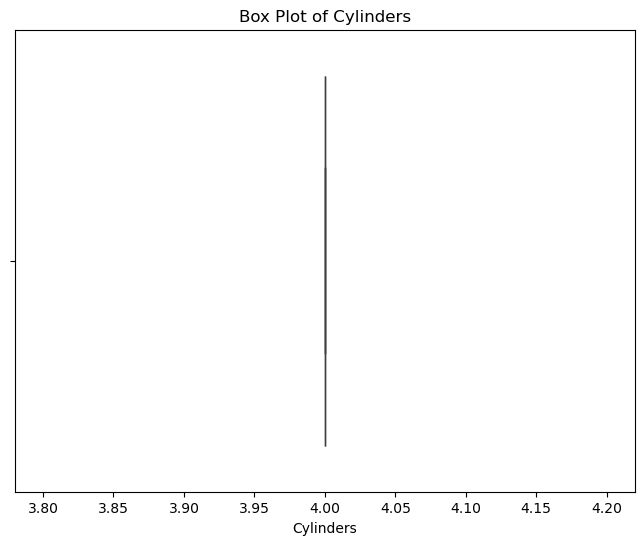

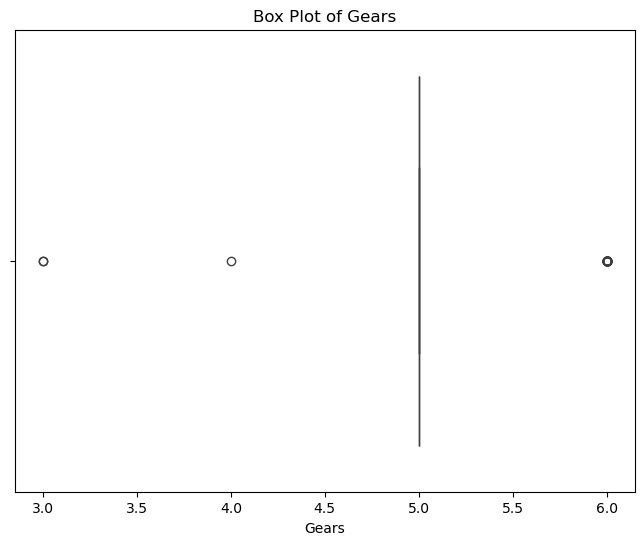

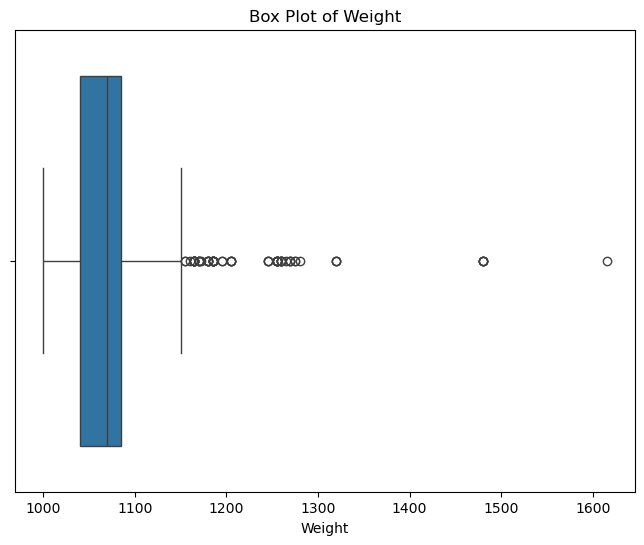

In [12]:
# Box plots for numerical variables

for column in df.select_dtypes(include=['number']).columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=df[column])
  plt.title(f'Box Plot of {column}')
  plt.show()

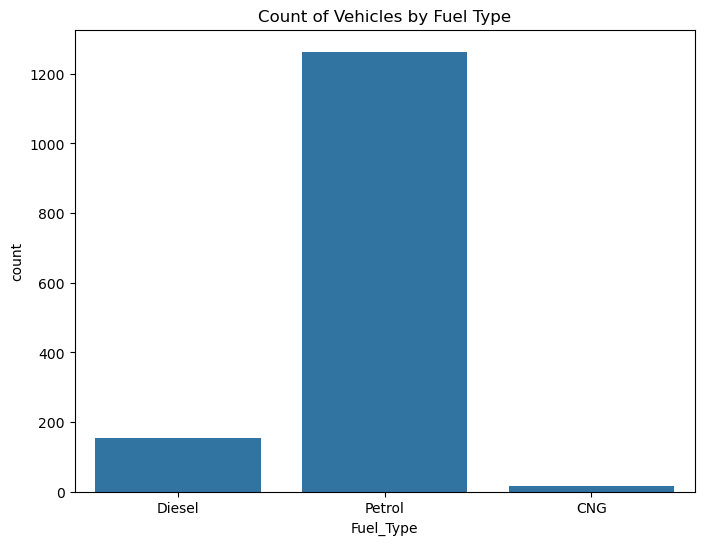

In [14]:
# Analyzing categorical variables (Fuel_Type)

if 'Fuel_Type' in df.columns:
  plt.figure(figsize=(8, 6))
  sns.countplot(x='Fuel_Type', data=df)
  plt.title('Count of Vehicles by Fuel Type')
  plt.show()

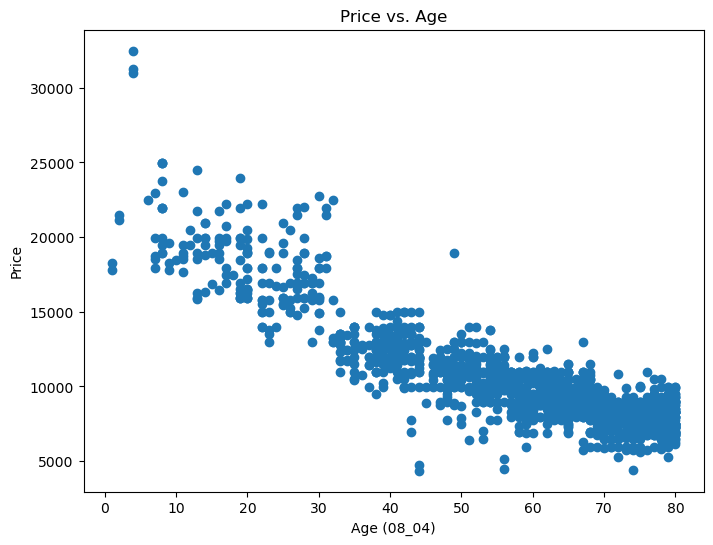

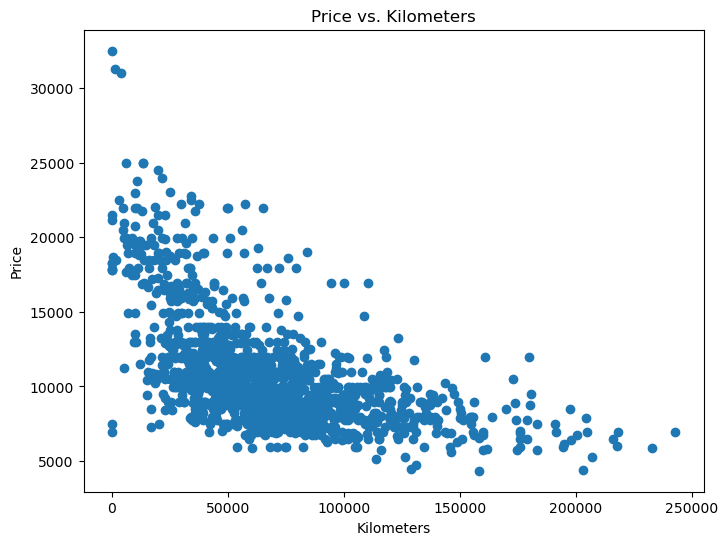

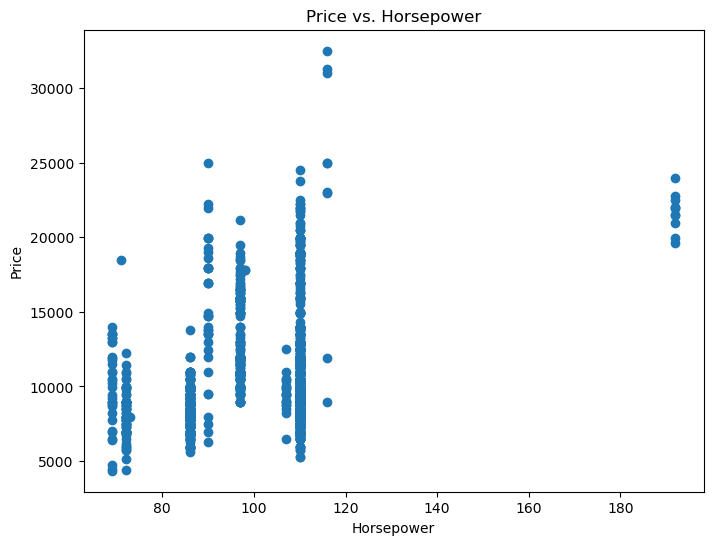

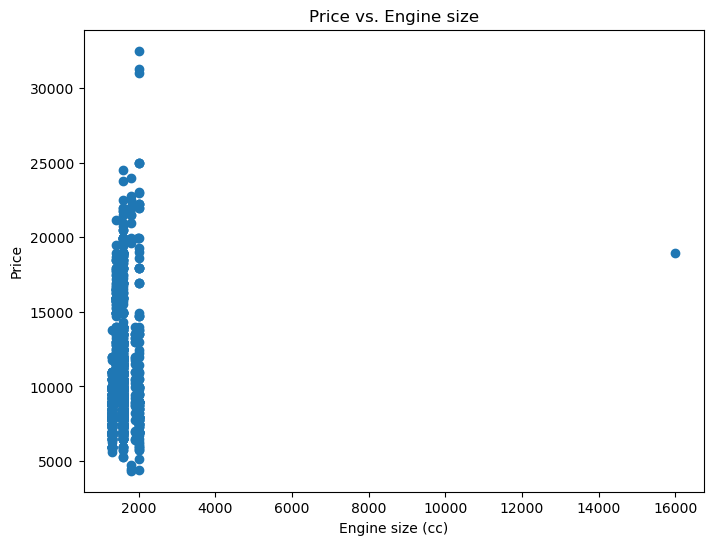

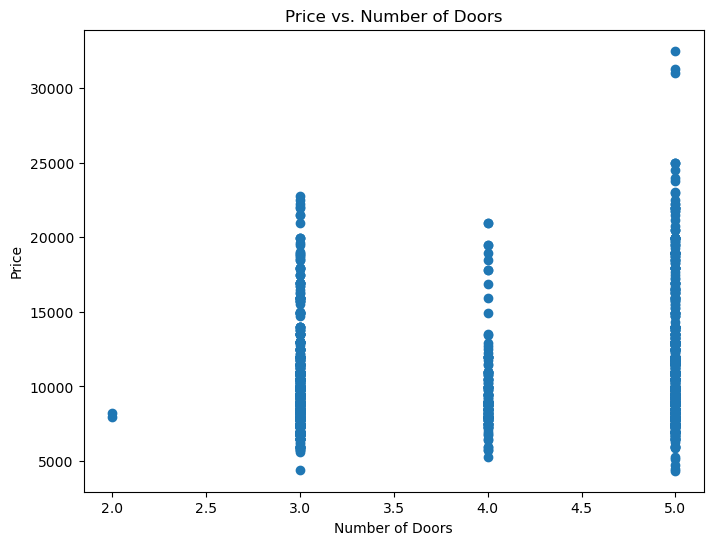

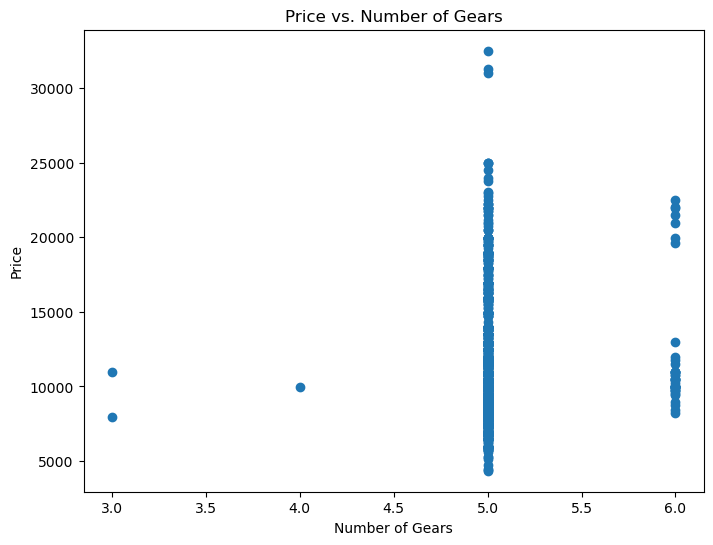

In [16]:
# Creating individual scatter plots for specific relationships

# Price vs. Age
plt.figure(figsize=(8, 6))
plt.scatter(df['Age_08_04'], df['Price'])
plt.xlabel('Age (08_04)')
plt.ylabel('Price')
plt.title('Price vs. Age')
plt.show()

# Price vs. KM
plt.figure(figsize=(8, 6))
plt.scatter(df['KM'], df['Price'])
plt.xlabel('Kilometers')
plt.ylabel('Price')
plt.title('Price vs. Kilometers')
plt.show()

# Price vs. HP
plt.figure(figsize=(8, 6))
plt.scatter(df['HP'], df['Price'])
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Price vs. Horsepower')
plt.show()

# Price vs. cc
plt.figure(figsize=(8, 6))
plt.scatter(df['cc'], df['Price'])
plt.xlabel('Engine size (cc)')
plt.ylabel('Price')
plt.title('Price vs. Engine size')
plt.show()

# Price vs. Doors
plt.figure(figsize=(8, 6))
plt.scatter(df['Doors'], df['Price'])
plt.xlabel('Number of Doors')
plt.ylabel('Price')
plt.title('Price vs. Number of Doors')
plt.show()

# Price vs. Gears
plt.figure(figsize=(8, 6))
plt.scatter(df['Gears'], df['Price'])
plt.xlabel('Number of Gears')
plt.ylabel('Price')
plt.title('Price vs. Number of Gears')
plt.show()

In [18]:
# Applying label encoding to fuel_type column as there are 3 categories in the column.
# They will be assigned values in an alphabetical order. CNG = 0, Diesel = 1, Petrol = 2.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

In [20]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,0,1300,3,4,5,1025
1432,10845,72,19000,2,86,0,1300,3,4,5,1015
1433,8500,71,17016,2,86,0,1300,3,4,5,1015
1434,7250,70,16916,2,86,0,1300,3,4,5,1015


In [22]:
# Correlation matrix

correlation_matrix = df.corr()
correlation_matrix

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,-0.022157,0.314990,0.033081,0.126389,0.185326,NaN,0.063104,0.581198
Age_08_04,-0.876590,1.000000,0.505672,0.080261,-0.156622,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.420586,-0.333538,-0.081854,0.102683,-0.036197,NaN,0.015023,-0.028598
Fuel_Type,-0.022157,0.080261,-0.420586,1.000000,0.409476,0.069718,-0.277239,-0.026935,NaN,0.069655,-0.505303
HP,0.314990,-0.156622,-0.333538,0.409476,1.000000,0.013144,0.035856,0.092424,NaN,0.209477,0.089614
Automatic,0.033081,0.031717,-0.081854,0.069718,0.013144,1.000000,0.066740,-0.027654,NaN,-0.098555,0.057249
cc,0.126389,-0.098084,0.102683,-0.277239,0.035856,0.066740,1.000000,0.079903,NaN,0.014629,0.335637
Doors,0.185326,-0.148359,-0.036197,-0.026935,0.092424,-0.027654,0.079903,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.069655,0.209477,-0.098555,0.014629,-0.160141,NaN,1.000000,0.020613


In [24]:
# Dropping cylinders column
# We can observe in the Correlation Matrix above that the cylinders column has no relation with any other variable.
# So we can drop it.

df = df.drop('Cylinders', axis=1)
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,5,1165
1,13750,23,72937,1,90,0,2000,3,5,1165
2,13950,24,41711,1,90,0,2000,3,5,1165
3,14950,26,48000,1,90,0,2000,3,5,1165
4,13750,30,38500,1,90,0,2000,3,5,1170
...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,0,1300,3,5,1025
1432,10845,72,19000,2,86,0,1300,3,5,1015
1433,8500,71,17016,2,86,0,1300,3,5,1015
1434,7250,70,16916,2,86,0,1300,3,5,1015


In [ ]:
# EDA Summary of ToyotaCorolla Dataset

# 1. Basic statistics (mean, median, std dev) have been calculated for numerical variables to understand the data's central tendency and dispersion. Data types and missing values have also been identified.
# 2. No missing values were found.
# 3. Box plots helped identify outliers and understand the spread of the data for each numerical variable.
# 4. Scatter plots were created to explore the relationships between Price and variables like Age, KM, HP, cc, Doors, and Gears.
# 5. The 'Fuel_Type' categorical variable was transformed using label encoding into numerical values for easier model building.
# 6. The 'Cylinders' column was dropped because it showed no significant correlation with other variables, suggesting it might not be a relevant feature for predicting the price.

In [26]:
# Splitting dataset into Training and Testing Sets where train=80% and test=20%

# Splitting x and y variables and creating new datasets.
X = df.drop('Price', axis = 1).values
y = df.iloc[:, 0].values.reshape(-1,1)

In [28]:
# Splitting the dataset into the Training set and Test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Shape of X_train: ",X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_test",y_test.shape)

Shape of X_train:  (1148, 9)
Shape of X_test:  (288, 9)
Shape of y_train:  (1148, 1)
Shape of y_test (288, 1)


In [30]:
# Training the first model using all columns.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create DataFrame with the correct column names
X_train_df = pd.DataFrame(X_train, columns=df.drop('Price', axis=1).columns)
X_test_df = pd.DataFrame(X_test, columns=df.drop('Price', axis=1).columns)  # Create X_test_df
Y_train_df = pd.DataFrame(y_train, columns=['Price'])
Y_test_df = pd.DataFrame(y_test, columns=['Price'])                         # Create y_test_df

# Model 1: Create and train the first model using the DataFrame with all column names
model1 = smf.ols('Price ~ Age_08_04 + KM + HP + cc + Doors + Gears + Weight + Fuel_Type', data=pd.concat([X_train_df, Y_train_df], axis=1))
results1 = model1.fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     946.7
Date:                Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                        18:41:05   Log-Likelihood:                -9867.5
No. Observations:                1148   AIC:                         1.975e+04
Df Residuals:                    1139   BIC:                         1.980e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.279e+04   1636.722     -7.812      0.0

In [32]:
# Interpret the coefficients from the model summary
results1.params

# Coefficient for Age is 120.
# This means that for every one-year increase in the age of the car (Age_08_04),
# the price of the car is predicted to decrease by approximately 120 units (currency).

# Interpretation for other coefficients follows the same logic.
# Positive coefficient for 'HP' means that higher horsepower is associated with higher price.
# Positive coefficient for 'cc' means that larger engine size is associated with higher price.
# Negative coefficient for 'KM' means that higher mileage is associated with lower price.

# R-squared value: It indicates the proportion of variance in the dependent variable explained by the independent variables. A higher R-squared value suggests a better fit.
# The p-values: They indicate the statistical significance of the coefficients.
# The residuals: They represent the difference between the actual and predicted values. They can be used to assess the model's accuracy and identify potential outliers.

Intercept   -12785.374005
Age_08_04     -120.868432
KM              -0.017109
HP              20.439193
cc              -0.063634
Doors          -41.520041
Gears          492.701127
Weight          23.797410
Fuel_Type      890.175154
dtype: float64

In [34]:
# RMSE of model 1

import numpy as np
# Make predictions on the test set using Model 1
y_pred_model1 = results1.predict(X_test_df)

# Calculate RMSE for Model 1
rmse_model1 = np.sqrt(mean_squared_error(y_test, y_pred_model1))
print("RMSE of Model 1:", rmse_model1)

RMSE of Model 1: 1451.9346609366228


In [36]:
# Create and train the second model
# Model 2: Using selected features (Age, KM, HP)

model2 = smf.ols('Price ~ Age_08_04 + KM + HP', data=pd.concat([X_train_df, Y_train_df], axis=1))
results2 = model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     1627.
Date:                Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                        18:41:38   Log-Likelihood:                -10082.
No. Observations:                1148   AIC:                         2.017e+04
Df Residuals:                    1144   BIC:                         2.019e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    1.66e+04    394.889     42.042      0.0

In [38]:
# RMSE for model 2

import numpy as np
# Make predictions on the test set using Model 2
y_pred_model2 = results2.predict(X_test_df)

# Calculate RMSE for Model 2
rmse_model2 = np.sqrt(mean_squared_error(y_test, y_pred_model2))
print("RMSE of Model 2:", rmse_model2)

RMSE of Model 2: 1590.8427891635731


In [40]:
# Create and train the third model
# Model 3: Using selected features (cc, Doors, Gears)

model3 = smf.ols('Price ~ cc + Doors + Gears', data=pd.concat([X_train_df, Y_train_df], axis=1))
results3 = model3.fit()
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     19.57
Date:                Thu, 27 Mar 2025   Prob (F-statistic):           2.24e-12
Time:                        18:41:46   Log-Likelihood:                -11007.
No. Observations:                1148   AIC:                         2.202e+04
Df Residuals:                    1144   BIC:                         2.204e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -660.7559   2812.234     -0.235      0.8

In [42]:
# RMSE for model 3

import numpy as np
# Make predictions on the test set using Model 3
y_pred_model3 = results3.predict(X_test_df)

# Calculate RMSE for Model 3
rmse_model3 = np.sqrt(mean_squared_error(y_test, y_pred_model3))
print("RMSE of Model 3:", rmse_model3)

RMSE of Model 3: 3509.8952566783573


In [44]:
# 4. Evaluate the performance of the models using R-squared and RMSE

# Calculate R-squared for each model
r2_model1 = r2_score(y_test, y_pred_model1)
r2_model2 = r2_score(y_test, y_pred_model2)
r2_model3 = r2_score(y_test, y_pred_model3)

print("R-squared of Model 1:", r2_model1)
print("R-squared of Model 2:", r2_model2)
print("R-squared of Model 3:", r2_model3)

# Compare the RMSE and R-squared values to determine the best model.
# Lower RMSE and higher R-squared indicate better performance.

print("\nModel Performance Comparison:")
print("Model 1 - RMSE:", rmse_model1, "R-squared:", r2_model1)
print("Model 2 - RMSE:", rmse_model2, "R-squared:", r2_model2)
print("Model 3 - RMSE:", rmse_model3, "R-squared:", r2_model3)


R-squared of Model 1: 0.8420034758607273
R-squared of Model 2: 0.8103259513824692
R-squared of Model 3: 0.07670241527742028

Model Performance Comparison:
Model 1 - RMSE: 1451.9346609366228 R-squared: 0.8420034758607273
Model 2 - RMSE: 1590.8427891635731 R-squared: 0.8103259513824692
Model 3 - RMSE: 3509.8952566783573 R-squared: 0.07670241527742028


In [ ]:
# As we can observe from the R2 and RMSE values above, Model 1 is the best model out of the three models.

In [46]:
# Applying Lasso method

import numpy as np
from sklearn.linear_model import Lasso

# Create and train the Lasso regression model
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Model:")
print("RMSE:", rmse_lasso)
print("R-squared:", r2_lasso)

print("Lasso Coefficients:", lasso_model.coef_)

Lasso Regression Model:
RMSE: 1447.6182565179897
R-squared: 0.8429414838867533
Lasso Coefficients: [-1.21372123e+02 -1.69928764e-02  8.49605132e+02  2.08317267e+01
  2.24725572e+02 -7.32847182e-02 -3.58991409e+01  5.01974246e+02
  2.34718712e+01]


In [48]:
# Applying Ridge method

import numpy as np
from sklearn.linear_model import Ridge

# Create and train the Ridge regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the model
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Model:")
print("RMSE:", rmse_ridge)
print("R-squared:", r2_ridge)

print("Ridge Coefficients:", ridge_model.coef_)

Ridge Regression Model:
RMSE: 1447.5171217859145
R-squared: 0.8429634282301912
Ridge Coefficients: [[-1.21416308e+02 -1.69724308e-02  8.51619534e+02  2.07801481e+01
   2.41303341e+02 -7.38416938e-02 -3.63199959e+01  5.18174870e+02
   2.34721914e+01]]


In [50]:
# Comparing all the models and selecting the best model.
# The best model should have lowest RMSE and highest R2 out of all the models.

print("\nModel Performance Comparison:")
print("Model 1 - RMSE:", rmse_model1, "R-squared:", r2_model1)
print("Model 2 - RMSE:", rmse_model2, "R-squared:", r2_model2)
print("Model 3 - RMSE:", rmse_model3, "R-squared:", r2_model3)
print("Lasso Regression - RMSE:", rmse_lasso, "R-squared:", r2_lasso)
print("Ridge Regression - RMSE:", rmse_ridge, "R-squared:", r2_ridge)

# Determine the best model based on RMSE and R-squared
best_model = "Model 1"
best_rmse = rmse_model1
best_r2 = r2_model1

if rmse_model2 < best_rmse:
    best_model = "Model 2"
    best_rmse = rmse_model2
    best_r2 = r2_model2
if rmse_model3 < best_rmse:
    best_model = "Model 3"
    best_rmse = rmse_model3
    best_r2 = r2_model3
if rmse_lasso < best_rmse:
    best_model = "Lasso Regression"
    best_rmse = rmse_lasso
    best_r2 = r2_lasso
if rmse_ridge < best_rmse:
    best_model = "Ridge Regression"
    best_rmse = rmse_ridge
    best_r2 = r2_ridge


print("\nBest Model:", best_model)
print("Best RMSE:", best_rmse)
print("Best R-squared:", best_r2)


Model Performance Comparison:
Model 1 - RMSE: 1451.9346609366228 R-squared: 0.8420034758607273
Model 2 - RMSE: 1590.8427891635731 R-squared: 0.8103259513824692
Model 3 - RMSE: 3509.8952566783573 R-squared: 0.07670241527742028
Lasso Regression - RMSE: 1447.6182565179897 R-squared: 0.8429414838867533
Ridge Regression - RMSE: 1447.5171217859145 R-squared: 0.8429634282301912

Best Model: Ridge Regression
Best RMSE: 1447.5171217859145
Best R-squared: 0.8429634282301912


In [ ]:
# Interview Questions:

# 1. What is Normalization & Standardization and how is it helpful?

# Normalization and Standardization

# Normalization (Min-Max Scaling):
# Rescales the data to a specific range (usually 0 to 1).
# Formula: X_norm = (X - X_min) / (X_max - X_min)

# Standardization (Z-score Scaling):
# Rescales the data to a specific range (-3 to +3).
# Transforms the data to have a mean of 0 and a standard deviation of 1.
# Formula: X_std = (X - mean) / standard deviation
# Useful when you want to reduce the impact of outliers.

# Why are they helpful?

# 1. Improved Model Performance:
# - Many machine learning algorithms are sensitive to the scale of the features.
# - Normalization and standardization ensure that all features contribute equally to the model, leading to improved performance.

# 2. Enhanced Interpretability:
# Normalization and standardization can make it easier to interpret the coefficients of a model.

# 3. Handling Outliers:
# Standardization can help reduce the impact of outliers on the model.
# Outliers can have a significant influence on the mean and standard deviation, which can lead to biased models.
# Standardization can mitigate this effect.

In [ ]:
# 2. What techniques can be used to address multicollinearity in multiple linear regression?

# Techniques to address multicollinearity:

# 1. Feature Selection:
# Remove one or more of the highly correlated variables.
# Choose the variable that is most relevant to the dependent variable or that has the strongest theoretical basis.
# Use techniques like LASSO, or Ridge regression to automatically select features.

# 2. Data Transformation:
# Combine highly correlated variables into a single variable (e.g., principal component analysis).
# Centering or standardizing the data can help to reduce the impact of multicollinearity.

# 3. Ridge Regression:
# Introduces a penalty term to the least squares method, which shrinks the coefficients towards zero.
# This helps to reduce the impact of multicollinearity by reducing the magnitude of the coefficients.

# 4. LASSO Regression:
# Also introduces a penalty term, but this one forces some coefficients to become exactly zero.
# Effectively performs feature selection by eliminating some variables.

# 5. Principal Component Analysis (PCA):
# Creates new uncorrelated variables (principal components) from the original correlated variables.
# The principal components capture the most variance in the data.
# We can then use these principal components in your regression model instead of the original variables.

# 6. Variance Inflation Factor (VIF):
# Measure the degree of multicollinearity between independent variables.
# A high VIF value (typically > 5 or 10) indicates a high degree of multicollinearity.

# 7. Centering Variables:
# Subtracting the mean of each independent variable from its values.

# Note: The best technique for addressing multicollinearity depends on the specific dataset and context.